大数の法則を理解する
試行回数を増やすと統計的確率が数学的確率に漸近することを示す

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'MS Gothic'

p = []
x = []

count = 0
trials = 10**6

for j in range(10):
    i = 0
    count = 0
    p = []
    x = []
    for i in range(1, int(trials) + 1):
        if random.randint(1, 6) == 6:
            count += 1

        if i % 10 == 0:
            p.append(count / i)
            x.append(i)

    plt.plot(x, p, label="相対度数（10回ごと）")
    plt.axhline(1/6, linestyle="--", label="1/6")
    plt.xlabel("試行回数")
    plt.ylabel("確率")
    plt.legend()
    plt.show()

n!の考え方を視覚的に認識させる
そのために樹形図を表示する

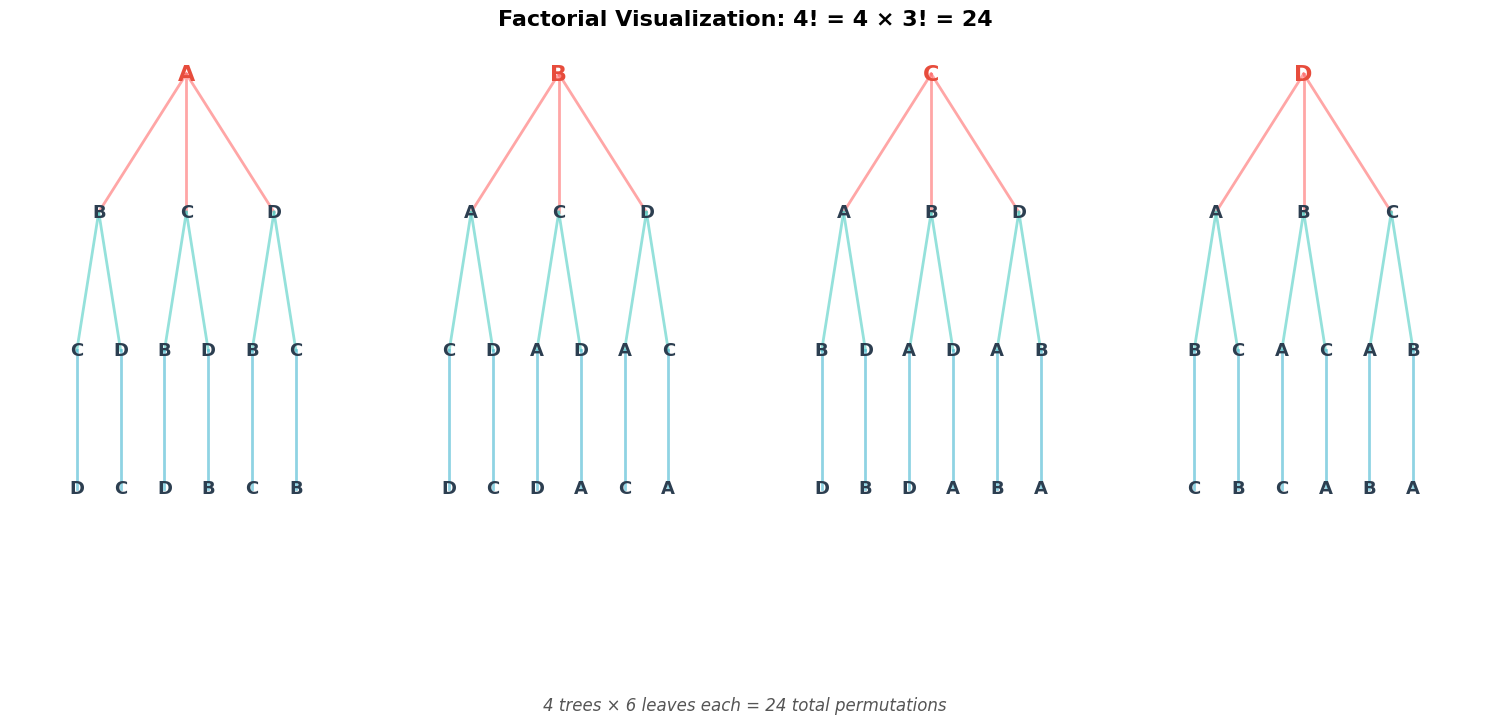

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ===== 設定 =====
N = 4
LABELS = ["A", "B", "C", "D", "E", "F"]
LEAF_GAP = 1.2      # 葉同士の間隔
LEVEL_GAP = 1.2     # 縦方向の間隔
TREE_GAP = 3.0      # 木と木の間隔
# =================

# 葉の数（= 部分階乗）を数える
def count_leaves(rest):
    if not rest:
        return 1
    total = 0
    for x in rest:
        total += count_leaves([r for r in rest if r != x])
    return total

# 色のグラデーション設定（深さに応じて色を変える）
def get_color(depth, max_depth):
    """深さに応じた色を返す"""
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
    return colors[depth % len(colors)]

# 描画本体（改良版）- 親ノードの位置を引数で受け取る
def draw_tree(rest, x_left, y, parent_x, depth=0, max_depth=None, root_label=None):
    if not rest:
        return
    
    # 最大深さの計算（初回のみ）
    if max_depth is None:
        max_depth = len(rest)
    
    # この階層全体の幅を計算
    total_width = count_leaves(rest) * LEAF_GAP
    
    for item in rest:
        new_rest = [r for r in rest if r != item]
        leaf_count = count_leaves(new_rest)
        
        # この枝が使う横幅
        width = leaf_count * LEAF_GAP
        
        # 子ノードの中心
        cx = x_left + width / 2
        cy = y - LEVEL_GAP
        
        # 枝を描画（親ノードから子ノードへ）
        edge_color = get_color(depth, max_depth)
        plt.plot([parent_x, cx], [y, cy], 
                linewidth=2, color=edge_color, alpha=0.6, zorder=1)
        
        # ノードのラベル（文字のみ）
        plt.text(cx, cy, item, ha="center", va="center", 
                fontsize=13, fontweight='bold', color='#2C3E50', zorder=4)
        
        # 再帰（このノードを親として、その位置を渡す）
        draw_tree(new_rest, x_left, cy, cx, depth + 1, max_depth, root_label)
        
        x_left += width

# メイン描画
items = LABELS[:N]

# 各木の幅を計算
single_tree_width = count_leaves(items[1:]) * LEAF_GAP  # 残りの要素から作られる木の幅
total_width = single_tree_width * N + TREE_GAP * (N - 1)  # 全体の幅

# 深さを計算
tree_depth = N  # 最大の深さはNレベル

# 画像サイズを動的に計算
# 幅：総幅に基づいて計算し、十分な余裕を持たせる
fig_width = max(15, total_width / 8)  # より広い幅を確保
# 高さ：深さに基づいて計算
fig_height = max(8, tree_depth * 2)

# フィギュア設定
plt.figure(figsize=(fig_width, fig_height))
plt.axis("off")

# 背景色を設定
ax = plt.gca()
ax.set_facecolor('#F8F9FA')

# 各ルートノードごとに独立した木を描画
current_x = 0

for root_item in items:
    # このルートノード以外の要素
    remaining = [item for item in items if item != root_item]
    
    # このルートノードの位置
    root_x = current_x + single_tree_width / 2
    root_y = 0
    
    # ルートノードのラベル
    plt.text(root_x, root_y, root_item, ha="center", va="center", 
            fontsize=16, fontweight='bold', color='#E74C3C', zorder=4)
    
    # この木を描画
    draw_tree(remaining, current_x, root_y, root_x, depth=0, root_label=root_item)
    
    # 次の木の開始位置
    current_x += single_tree_width + TREE_GAP

# タイトルと統計情報
total_permutations = 1
for i in range(1, N + 1):
    total_permutations *= i

plt.title(f'Factorial Visualization: {N}! = {N} × {N-1}! = {total_permutations}', 
         fontsize=16, fontweight='bold', pad=20)

# 説明テキスト
explanation = f'{N} trees × {total_permutations // N} leaves each = {total_permutations} total permutations'
plt.text(total_width / 2, -LEVEL_GAP * (N + 0.5), explanation, 
        ha="center", va="top", fontsize=12, style='italic', color='#555')

# 余白を調整
plt.tight_layout()
plt.show()

In [7]:
import random
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Yu Gothic'

TICKET_PRICE = 300
N = 6

# (等級名, 桁数, 確率, 賞金)
PRIZES = [
    ("1等", 6, 1/1_000_000, 30000000),
    ("2等", 5, 1/100_000,     3000000),
    ("3等", 4, 1/10_000,       300000),
    ("4等", 3, 1/1_000,         30000),
    ("5等", 2, 1/100,             3000),
    ("6等", 1, 1/10,              300),
]

WINNING_NUMBER = f"{random.randint(0, 10**N - 1):0{N}d}"

print(f"当選番号: {WINNING_NUMBER}\n")

当選番号: 415533



In [19]:
def judge(ticket_number: str):
    for grade, digits, _, prize in PRIZES:
        if ticket_number[-digits:] == WINNING_NUMBER[-digits:]:
            return grade, prize
    return "はずれ", 0

def expected_value():
    """賞金の期待値を計算"""
    ev = 0
    for _, _, prob, prize in PRIZES:
        ev += prob * prize
    return ev

# Part A: 1回の購入
ticket = f"{random.randint(0, 10**N - 1):0{N}d}"
grade, prize = judge(ticket)

print("=== Part A: 1回の結果 ===")
print(f"購入番号: {ticket}")
print(f"結果: {grade}")
print(f"賞金: {prize:,}円")
print(f"利益: {prize - TICKET_PRICE:+,}円")
print(f"\n賞金の期待値: {expected_value():.2f}円")
print(f"還元率: {expected_value() / TICKET_PRICE * 100:.1f}%\n")


=== Part A: 1回の結果 ===
購入番号: 632303
結果: 6等
賞金: 300円
利益: +0円

賞金の期待値: 180.00円
還元率: 60.0%



In [21]:
# Part B: 10万回の試行実験
TRIALS = 100_000
total_prize = 0

for _ in range(TRIALS):
    ticket = f"{random.randint(0, 10**N - 1):0{N}d}"
    _, prize = judge(ticket)
    total_prize += prize

average_prize = total_prize / TRIALS
average_profit = average_prize - TICKET_PRICE

print("=== Part B: シミュレーション結果 ===")
print(f"試行回数: {TRIALS:,}回")
print(f"平均賞金: {average_prize:.2f}円")
print(f"平均利益: {average_profit:.2f}円")
print(f"理論期待値: {expected_value():.2f}円")
print(f"差: {abs(average_prize - expected_value()):.2f}円")


=== Part B: シミュレーション結果 ===
試行回数: 100,000回
平均賞金: 109.28円
平均利益: -190.72円
理論期待値: 180.00円
差: 70.72円


=== Part C: 期待値への収束の可視化 ===


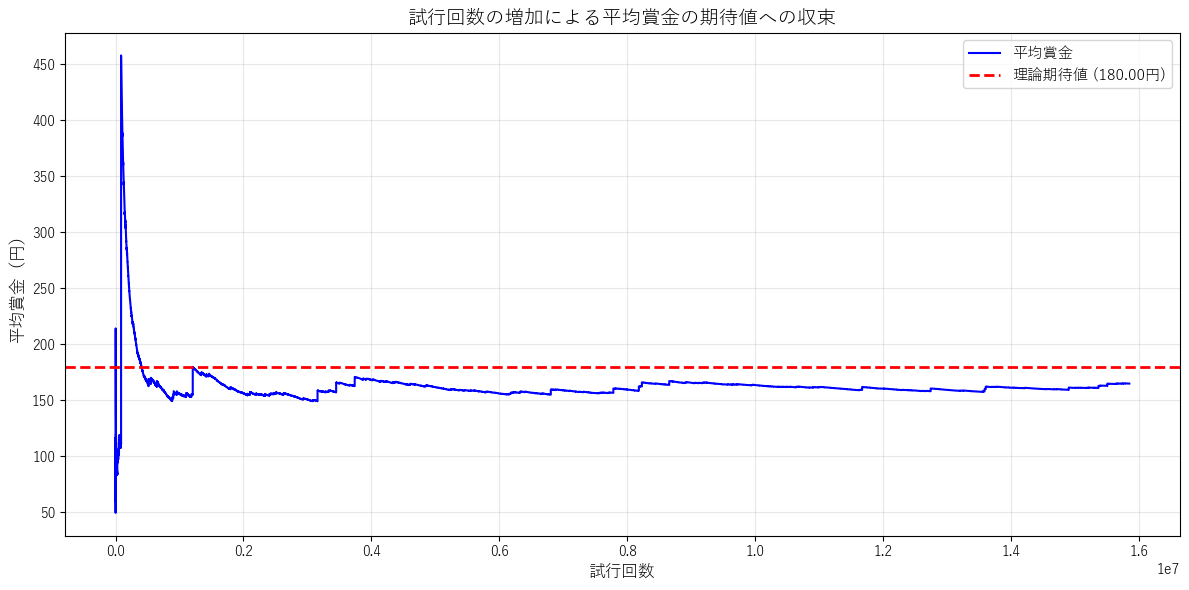

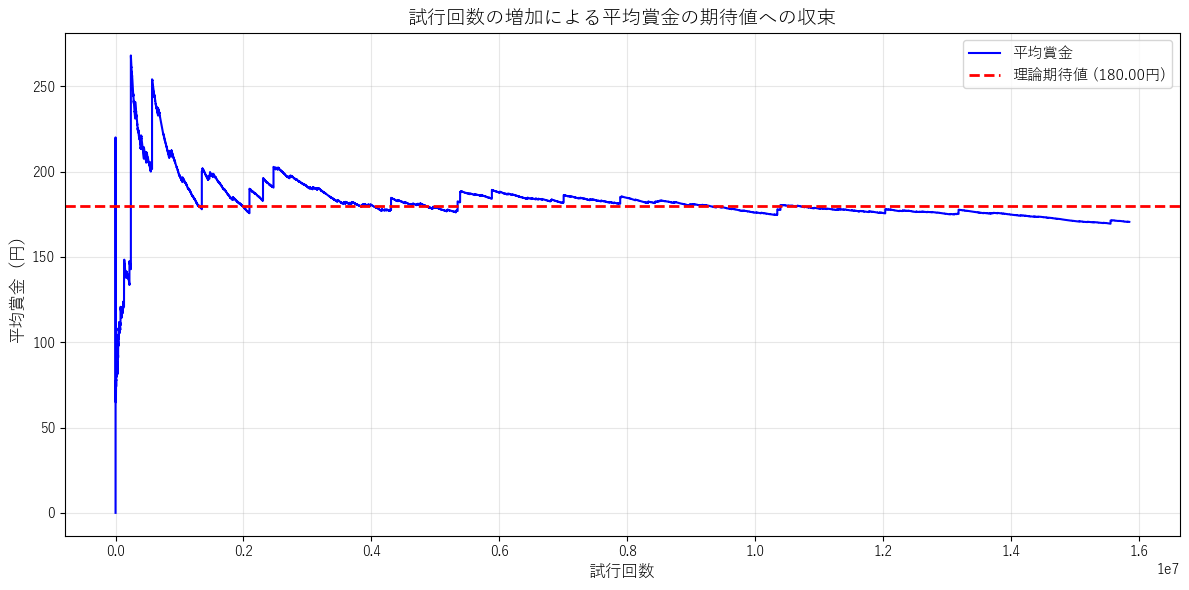

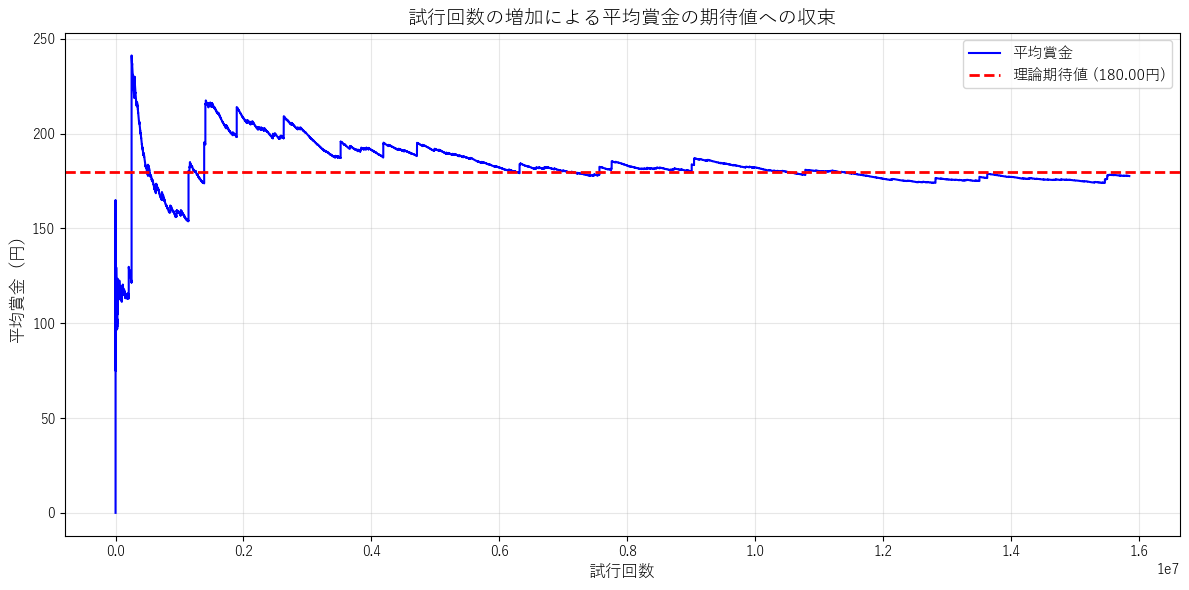

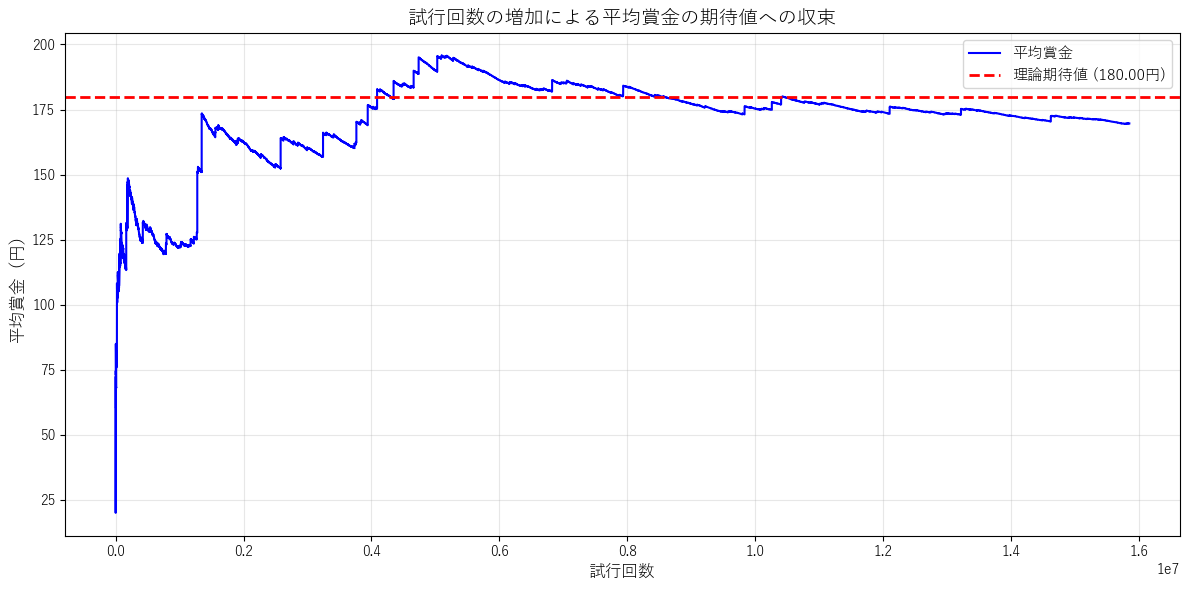

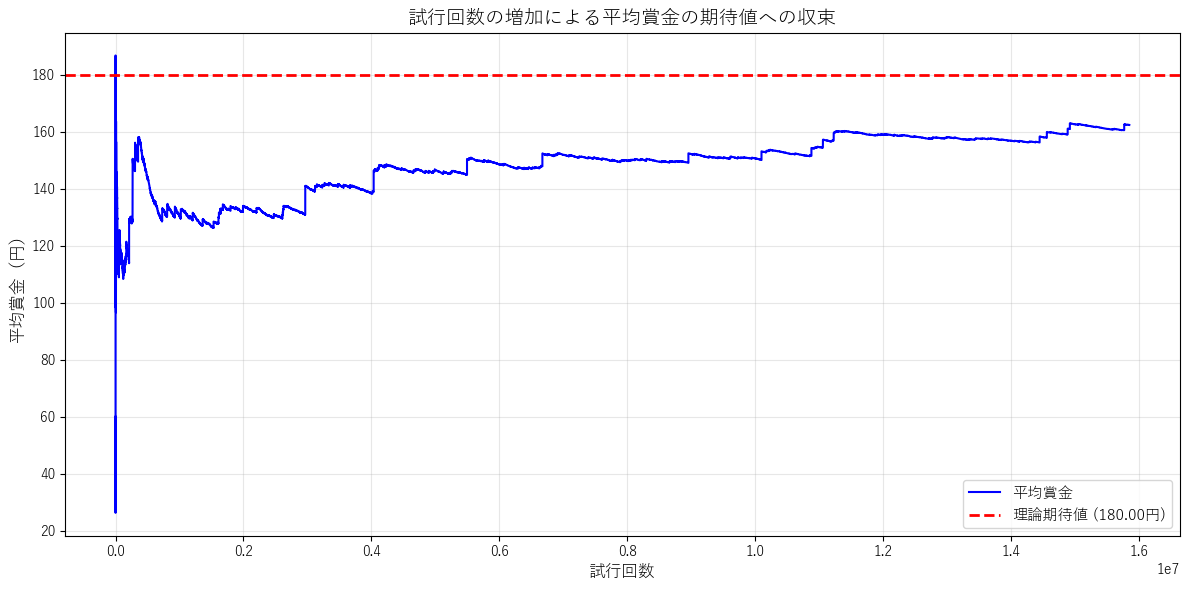


最終的な平均賞金: 162.43円
理論期待値: 180.00円
誤差: 17.57円


In [22]:
# Part C: 試行回数と平均賞金の収束を可視化
print("=== Part C: 期待値への収束の可視化 ===")
MAX_TRIALS = int(10**7.2)      # 一回当たりの試行回数
SAMPLE_INTERVAL = 10           # データを記録するタイミング
FOR_TRIAL = 5                 # グラフを表示する回数

for _ in range(FOR_TRIAL):
    trials_list = []
    average_prizes = []

    total_prize_cumulative = 0

    for i in range(1, MAX_TRIALS + 1):
        ticket = f"{random.randint(0, 10**N - 1):0{N}d}"
        _, prize = judge(ticket)
        total_prize_cumulative += prize
        
        if i % SAMPLE_INTERVAL == 0:
            trials_list.append(i)
            average_prizes.append(total_prize_cumulative / i)

    plt.figure(figsize=(12, 6))
    plt.plot(trials_list, average_prizes, label='平均賞金', linewidth=1.5, color='blue')
    plt.axhline(y=expected_value(), color='red', linestyle='--', 
                linewidth=2, label=f'理論期待値 ({expected_value():.2f}円)')

    plt.xlabel('試行回数', fontsize=12)
    plt.ylabel('平均賞金（円）', fontsize=12)
    plt.title('試行回数の増加による平均賞金の期待値への収束', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()

print(f"\n最終的な平均賞金: {average_prizes[-1]:.2f}円")
print(f"理論期待値: {expected_value():.2f}円")
print(f"誤差: {abs(average_prizes[-1] - expected_value()):.2f}円")